# 01. Phân tích Khám phá Dữ liệu (EDA) - VN50 Stocks

Notebook này thực hiện khám phá cấu trúc dữ liệu lịch sử của 50 mã cổ phiếu hàng đầu Việt Nam (30 mã VN30 và 20 mã Midcap có thanh khoản cao nhất). Phân tích này đóng vai trò quan trọng trong việc định hình các giả định tiền xử lý, kiểm tra tính phi dừng (non-stationarity), độ tương quan ngành, và chứng minh trực quan sự cần thiết của phương pháp chuẩn hóa cục bộ theo cửa sổ (sliding window normalization) cho mô hình **Kronos**.

## 1. Thiết lập và nạp thư viện

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import scipy.stats as stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Thiết lập phong cách hiển thị biểu đồ
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_palette("viridis")

DATA_DIR = os.path.join("..", "data")
print(f"Thư mục dữ liệu: {os.path.abspath(DATA_DIR)}")

Thư mục dữ liệu: c:\Users\USER\Desktop\Stock-VN-forecashing\data


## 2. Minh họa Biểu đồ Nến & 6 Biến số của một Cổ phiếu

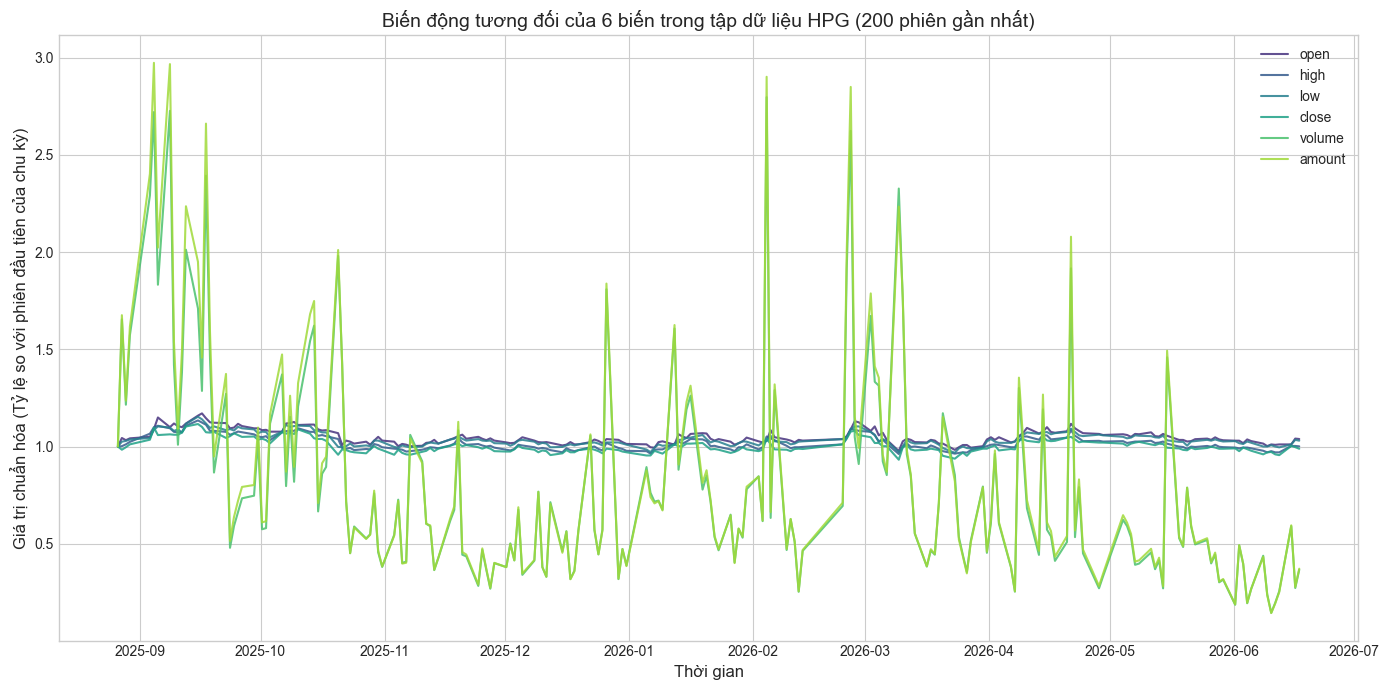

In [2]:
# Lấy mã HPG làm ví dụ minh họa
hpg_path = os.path.join(DATA_DIR, "HPG.csv")
df_hpg = pd.read_csv(hpg_path)
df_hpg['timestamps'] = pd.to_datetime(df_hpg['timestamps'])

# 1. Đồ thị nến tương tác (Plotly) - Giới hạn 100 phiên để tránh lag
df_sub = df_hpg.tail(100)
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    vertical_spacing=0.05, 
                    subplot_titles=('Giá HPG (OHLC)', 'Khối lượng giao dịch'), 
                    row_width=[0.3, 0.7])

fig.add_trace(go.Candlestick(
    x=df_sub['timestamps'],
    open=df_sub['open'],
    high=df_sub['high'],
    low=df_sub['low'],
    close=df_sub['close'], 
    name="Nến giá"
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df_sub['timestamps'], 
    y=df_sub['volume'], 
    name="Khối lượng",
    marker_color='lightblue'
), row=2, col=1)

fig.update_layout(xaxis_rangeslider_visible=False, height=600, title_text="Đồ thị nến HPG (100 phiên gần nhất)")
fig.show()

# 2. Biểu đồ đường của tất cả 6 biến (chuẩn hóa tỷ lệ so với phiên đầu tiên)
plt.figure(figsize=(14, 7))
df_sub_line = df_hpg.tail(200).copy()
cols_to_plot = ['open', 'high', 'low', 'close', 'volume', 'amount']
for col in cols_to_plot:
    scaled_series = df_sub_line[col] / df_sub_line[col].iloc[0]
    plt.plot(df_sub_line['timestamps'], scaled_series, label=col, alpha=0.85)

plt.title("Biến động tương đối của 6 biến trong tập dữ liệu HPG (200 phiên gần nhất)")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị chuẩn hóa (Tỷ lệ so với phiên đầu tiên của chu kỳ)")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Kiểm tra sức khỏe dữ liệu (Data Sanity Check)

,Symbol,Start Date,End Date,Total Sessions,History Length (Years)
0,ACB,2018-06-19 09:00:00,2026-06-17 09:00:00,1992,7.968
1,ANV,2018-06-19 09:00:00,2026-06-17 09:00:00,1997,7.988
2,BCM,2018-06-19 09:00:00,2026-06-17 09:00:00,1980,7.920
3,BID,2018-06-19 09:00:00,2026-06-17 09:00:00,1997,7.988
4,BVH,2018-06-19 09:00:00,2026-06-17 09:00:00,1997,7.988


C:\Users\USER\AppData\Local\Temp\ipykernel_1608\424287973.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='Symbol', y='History Length (Years)', palette='viridis')


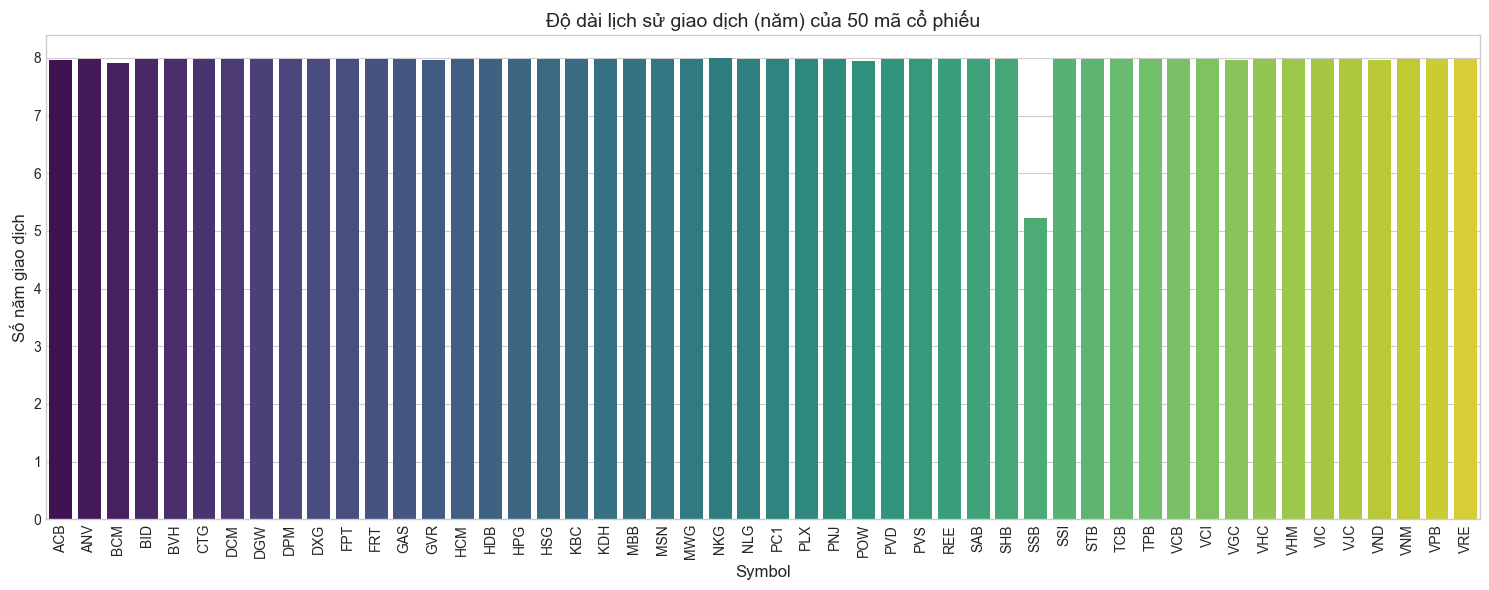

In [3]:
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
summary_data = []
all_dates = set()

# Quét qua toàn bộ dữ liệu
for fpath in csv_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    df['timestamps'] = pd.to_datetime(df['timestamps'])
    
    start_date = df['timestamps'].min()
    end_date = df['timestamps'].max()
    num_rows = len(df)
    all_dates.update(df['timestamps'].unique())
    
    summary_data.append({
        'Symbol': symbol,
        'Start Date': start_date,
        'End Date': end_date,
        'Total Sessions': num_rows,
        'History Length (Years)': num_rows / 250.0  # Ước tính 250 ngày giao dịch/năm
    })

summary_df = pd.DataFrame(summary_data).sort_values('Symbol').reset_index(drop=True)
display(summary_df.head())

# Trực quan hóa độ dài lịch sử
plt.figure(figsize=(15, 6))
sns.barplot(data=summary_df, x='Symbol', y='History Length (Years)', palette='viridis')
plt.xticks(rotation=90)
plt.title("Độ dài lịch sử giao dịch (năm) của 50 mã cổ phiếu")
plt.ylabel("Số năm giao dịch")
plt.tight_layout()
plt.show()

## 4. Xác minh Giá đóng cửa Điều chỉnh (Adjusted Close Verification)

Chúng ta cần kiểm tra xem chuỗi giá đóng cửa có bị lỗi nhảy cóc cơ học (gap down) do chia tách/chia cổ tức hay không. Hãy quan sát đồ thị giá đóng cửa của FPT và HPG tại các ngày chia tách lịch sử để đảm bảo tính trơn tru.

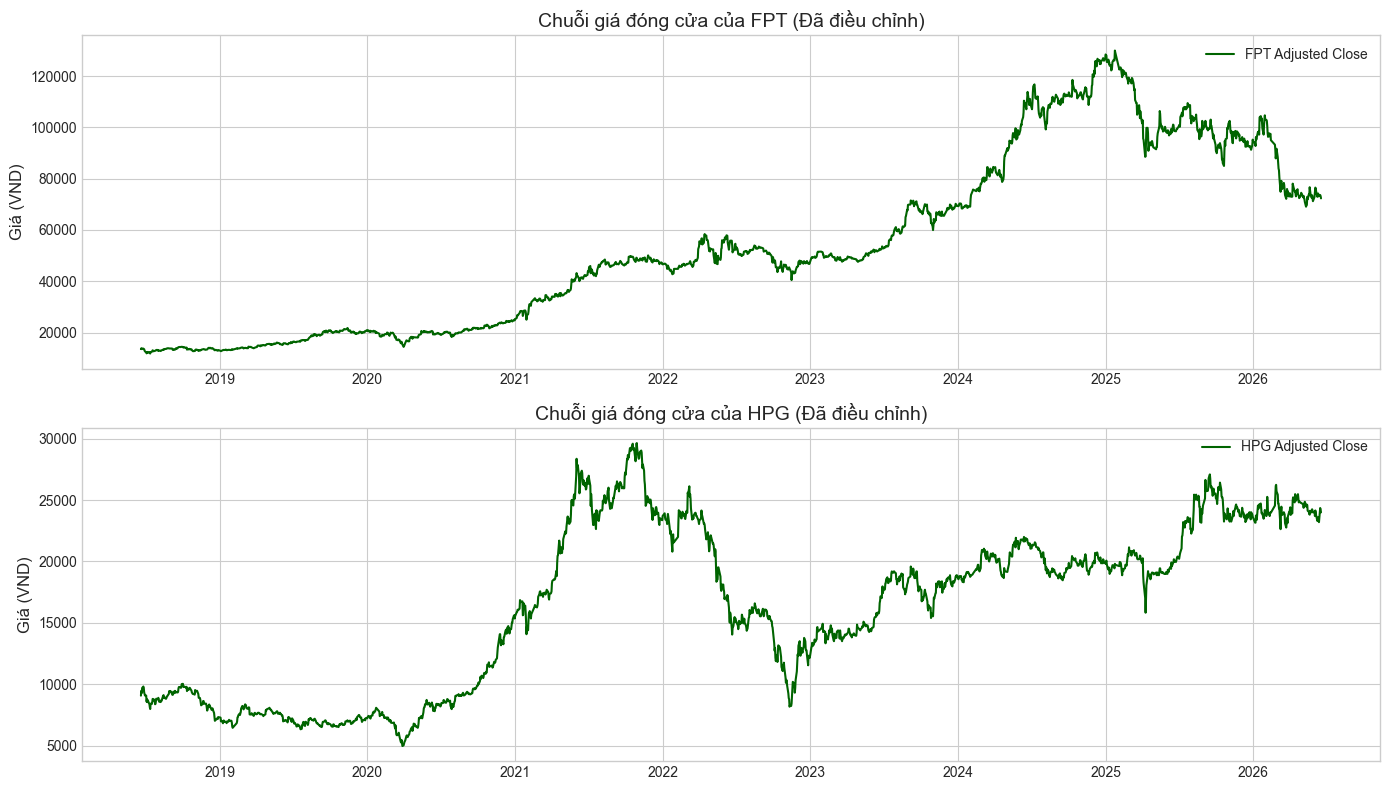

In [4]:
verify_symbols = ['FPT', 'HPG']
fig, axes = plt.subplots(len(verify_symbols), 1, figsize=(14, 8), sharex=False)

for i, symbol in enumerate(verify_symbols):
    fpath = os.path.join(DATA_DIR, f"{symbol}.csv")
    df = pd.read_csv(fpath)
    df['timestamps'] = pd.to_datetime(df['timestamps'])
    
    axes[i].plot(df['timestamps'], df['close'], label=f"{symbol} Adjusted Close", color='darkgreen')
    axes[i].set_title(f"Chuỗi giá đóng cửa của {symbol} (Đã điều chỉnh)")
    axes[i].set_ylabel("Giá (VND)")
    axes[i].legend()

plt.tight_layout()
plt.show()

## 5. Phát hiện Điểm Giao dịch trống & Đình chỉ Giao dịch (Suspension Detector)

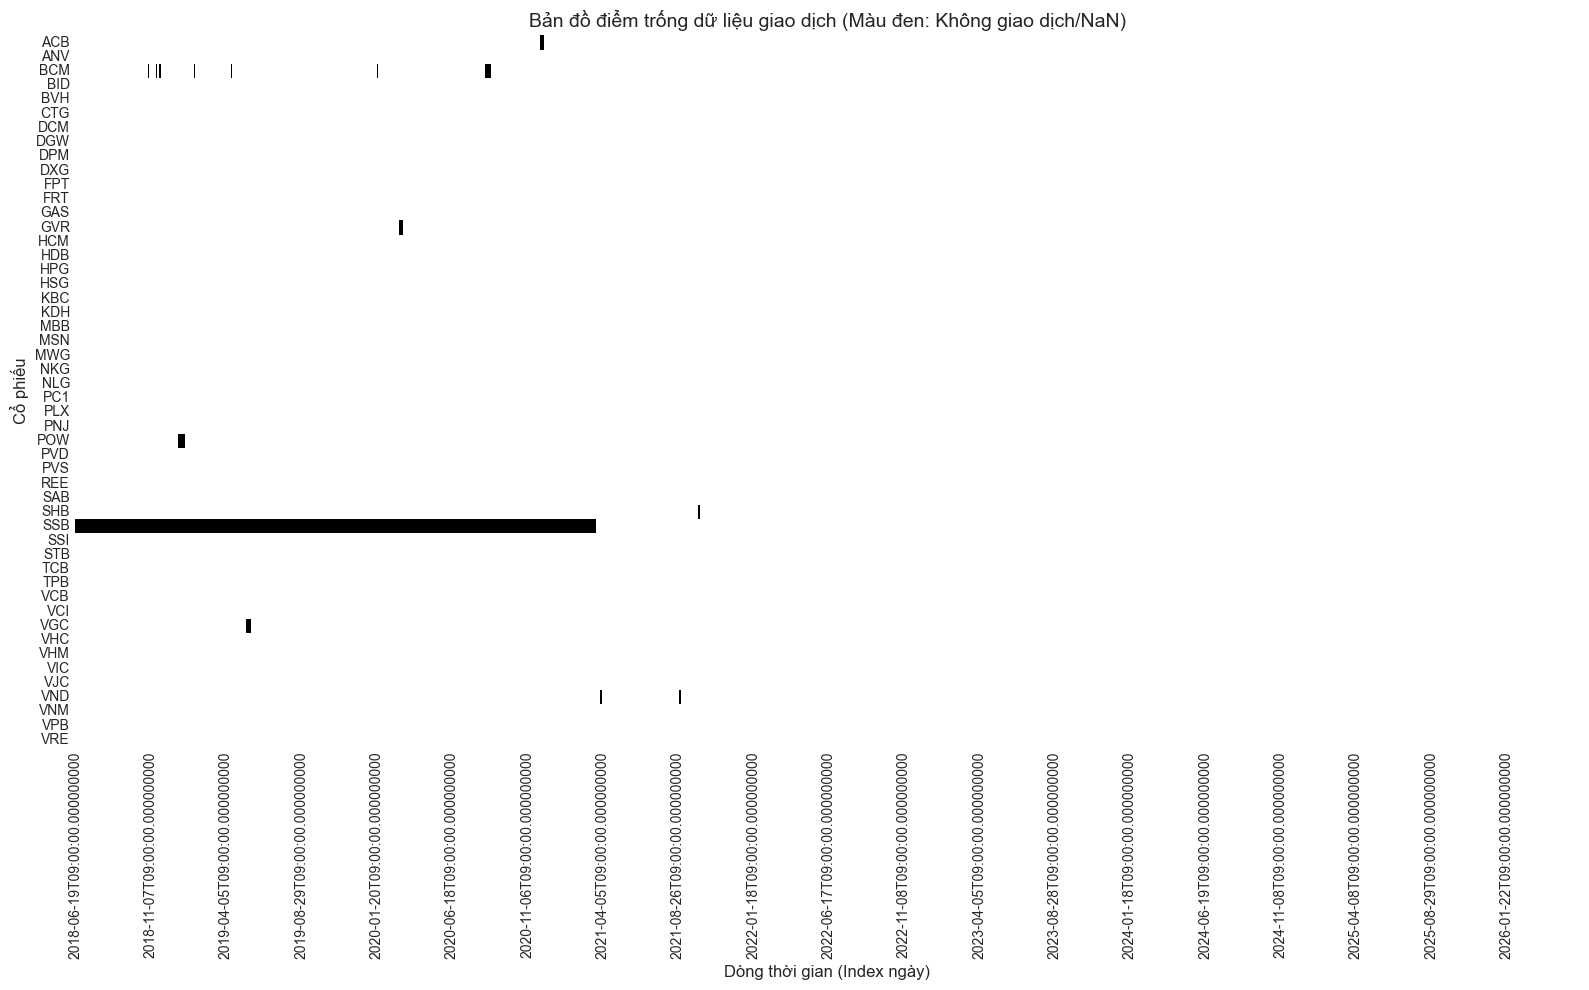

[!] Cổ phiếu BCM có chu kỳ đi ngang dài nhất: 6 ngày (Khả năng bị ngừng giao dịch)
[!] Cổ phiếu DCM có chu kỳ đi ngang dài nhất: 6 ngày (Khả năng bị ngừng giao dịch)
[!] Cổ phiếu GVR có chu kỳ đi ngang dài nhất: 6 ngày (Khả năng bị ngừng giao dịch)
[!] Cổ phiếu SAB có chu kỳ đi ngang dài nhất: 6 ngày (Khả năng bị ngừng giao dịch)
[!] Cổ phiếu SHB có chu kỳ đi ngang dài nhất: 7 ngày (Khả năng bị ngừng giao dịch)
[!] Cổ phiếu SSB có chu kỳ đi ngang dài nhất: 7 ngày (Khả năng bị ngừng giao dịch)


In [5]:
# Tạo dòng thời gian chung đại diện cho toàn bộ ngày giao dịch thực tế của thị trường (Union of all timestamps)
union_dates = sorted(list(all_dates))
timeline_df = pd.DataFrame(index=union_dates)

# Đếm số ngày trống dữ liệu khi map từng mã lên dòng thời gian chung
missing_map = {}
for fpath in csv_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    df['timestamps'] = pd.to_datetime(df['timestamps'])
    df_indexed = df.set_index('timestamps')
    
    # Tìm các ngày trống dữ liệu giao dịch so với Union timeline
    missing_days = timeline_df.join(df_indexed, how='left')
    missing_map[symbol] = missing_days['close'].isnull().astype(int)

missing_heatmap_df = pd.DataFrame(missing_map).T

plt.figure(figsize=(16, 10))
sns.heatmap(missing_heatmap_df, cmap='binary', cbar=False, xticklabels=100)
plt.title("Bản đồ điểm trống dữ liệu giao dịch (Màu đen: Không giao dịch/NaN)")
plt.xlabel("Dòng thời gian (Index ngày)")
plt.ylabel("Cổ phiếu")
plt.tight_layout()
plt.show()

# Kiểm tra chu kỳ đi ngang nhân tạo (Flatline do ffill dài ngày)
for fpath in csv_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    
    # Tìm số ngày đóng cửa bằng nhau liên tiếp
    consec_flat = (df['close'] == df['close'].shift(1)).astype(int)
    # Tạo nhóm tích lũy ngày bằng nhau
    flat_groups = consec_flat.groupby((consec_flat == 0).cumsum()).cumsum()
    max_flat = flat_groups.max()
    
    if max_flat > 5:
        print(f"[!] Cổ phiếu {symbol} có chu kỳ đi ngang dài nhất: {max_flat} ngày (Khả năng bị ngừng giao dịch)")

## 6. Phân phối Log-Return & Hiệu ứng Cắt cụt biên độ (Censored Tails)

Theo quy định của các sở giao dịch chứng khoán tại Việt Nam, biên độ biến động trần/sàn hàng ngày bị giới hạn (HOSE: +/- 7%, HNX: +/- 10%). Điều này tạo ra sự phân phối bị "cắt cụt" đột ngột ở hai rìa đuôi.

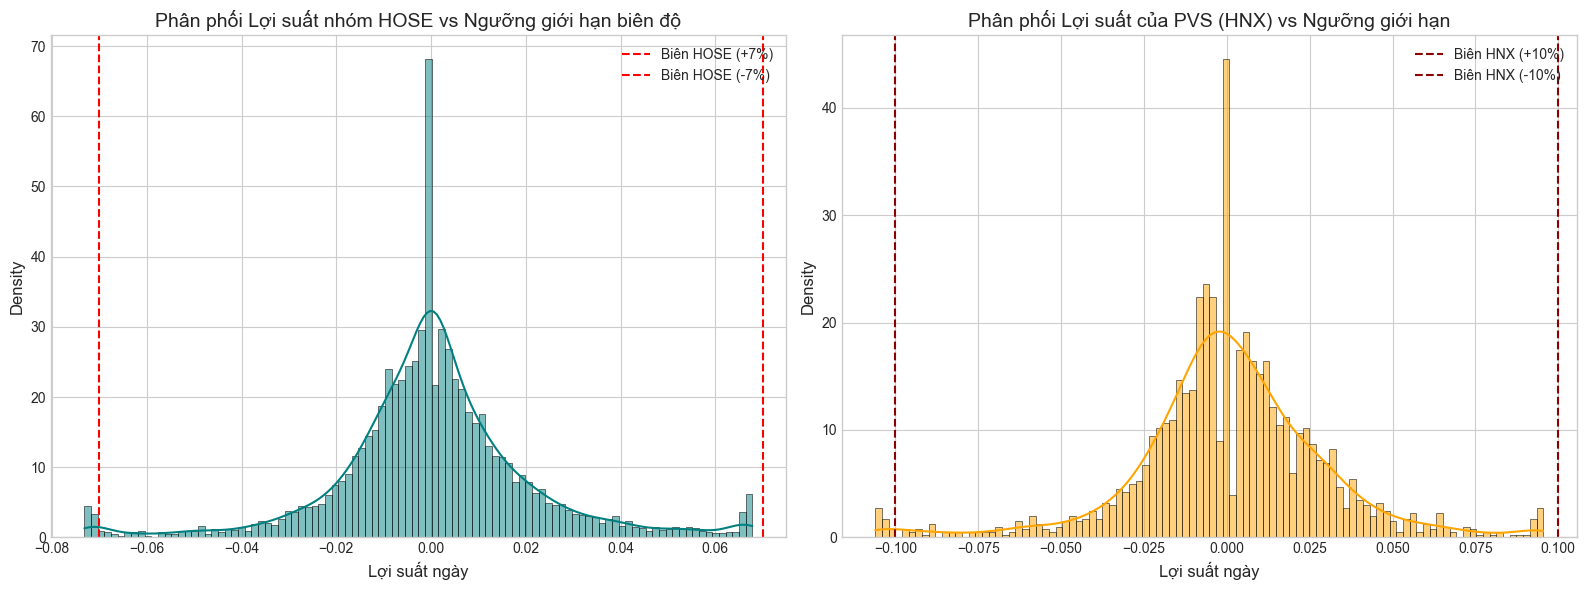

In [6]:
# Phân tách các mã thuộc HOSE và HNX
# PVS là mã duy nhất thuộc HNX trong tập VN50, còn lại thuộc HOSE
symbols_hose = ['HPG', 'SSI', 'VCB', 'VIC']
symbol_hnx = 'PVS'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Đồ thị phân phối nhóm HOSE
returns_hose = []
for sym in symbols_hose:
    df = pd.read_csv(os.path.join(DATA_DIR, f"{sym}.csv"))
    ret = np.log(df['close'] / df['close'].shift(1)).dropna()
    returns_hose.extend(ret.values)

sns.histplot(returns_hose, kde=True, stat="density", ax=axes[0], color='teal', bins=100)
axes[0].axvline(0.07, color='red', linestyle='--', linewidth=1.5, label='Biên HOSE (+7%)')
axes[0].axvline(-0.07, color='red', linestyle='--', linewidth=1.5, label='Biên HOSE (-7%)')
axes[0].set_title("Phân phối Lợi suất nhóm HOSE vs Ngưỡng giới hạn biên độ")
axes[0].set_xlabel("Lợi suất ngày")
axes[0].legend()

# 2. Đồ thị phân phối mã HNX (PVS)
df_pvs = pd.read_csv(os.path.join(DATA_DIR, f"{symbol_hnx}.csv"))
returns_hnx = np.log(df_pvs['close'] / df_pvs['close'].shift(1)).dropna()

sns.histplot(returns_hnx, kde=True, stat="density", ax=axes[1], color='orange', bins=100)
axes[1].axvline(0.10, color='darkred', linestyle='--', linewidth=1.5, label='Biên HNX (+10%)')
axes[1].axvline(-0.10, color='darkred', linestyle='--', linewidth=1.5, label='Biên HNX (-10%)')
axes[1].set_title(f"Phân phối Lợi suất của {symbol_hnx} (HNX) vs Ngưỡng giới hạn")
axes[1].set_xlabel("Lợi suất ngày")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Kiểm chứng Đuôi béo (Fat Tails) qua Q-Q Plot

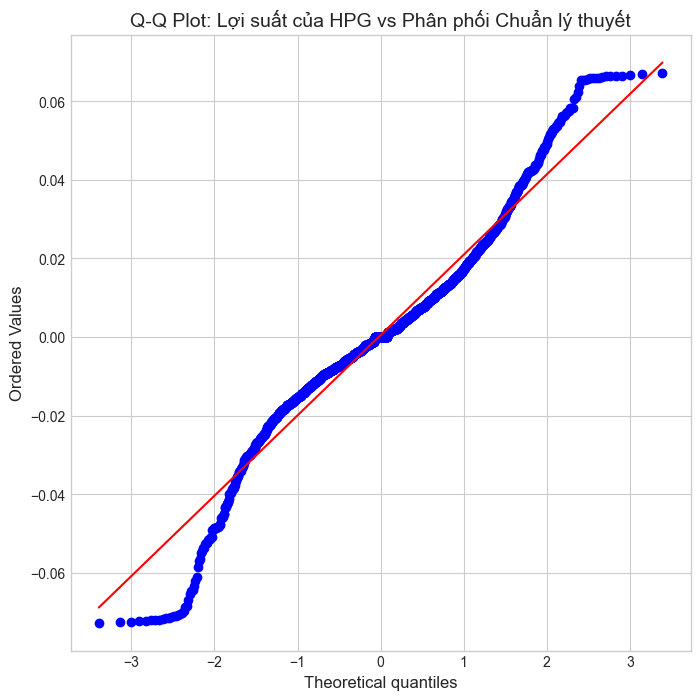

Độ nhọn vượt mức (Excess Kurtosis) của HPG: 2.007
Giải thích: Độ nhọn > 0 (đặc biệt lớn hơn 3) chứng minh phân phối lợi suất thực tế có đuôi béo,
các biến động cực đoan xuất hiện nhiều hơn so với giả định phân phối chuẩn.


In [7]:
# Q-Q Plot của HPG so với phân phối chuẩn lý thuyết
df_hpg_ret = pd.read_csv(os.path.join(DATA_DIR, "HPG.csv"))
returns_hpg = np.log(df_hpg_ret['close'] / df_hpg_ret['close'].shift(1)).dropna()

plt.figure(figsize=(8, 8))
stats.probplot(returns_hpg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Lợi suất của HPG vs Phân phối Chuẩn lý thuyết")
plt.show()

excess_kurt = stats.kurtosis(returns_hpg)
print(f"Độ nhọn vượt mức (Excess Kurtosis) của HPG: {excess_kurt:.3f}")
print("Giải thích: Độ nhọn > 0 (đặc biệt lớn hơn 3) chứng minh phân phối lợi suất thực tế có đuôi béo,")
print("các biến động cực đoan xuất hiện nhiều hơn so với giả định phân phối chuẩn.")

## 8. Sự Tụ cụm Biến động (Volatility Clustering)

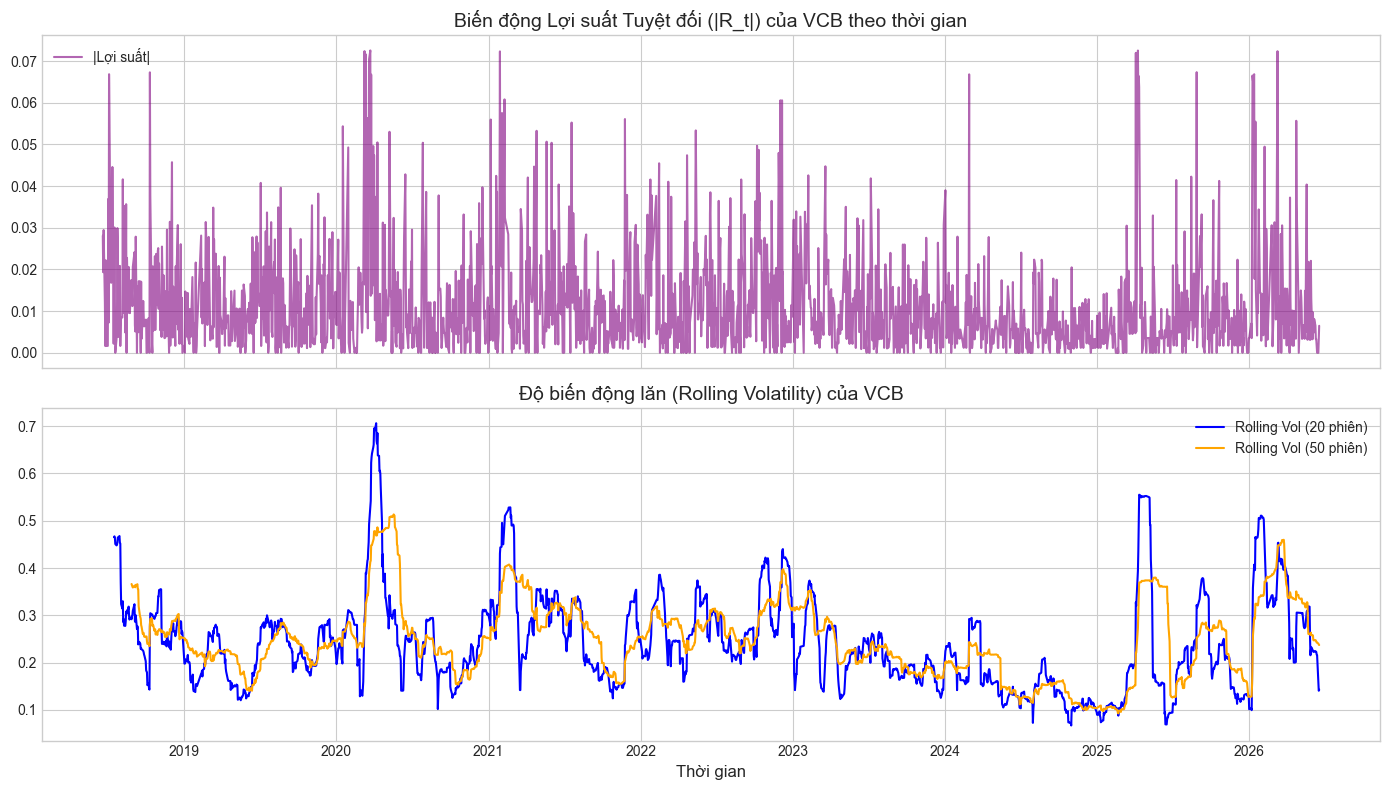

In [8]:
df_vcb = pd.read_csv(os.path.join(DATA_DIR, "VCB.csv"))
df_vcb['timestamps'] = pd.to_datetime(df_vcb['timestamps'])
df_vcb['returns'] = np.log(df_vcb['close'] / df_vcb['close'].shift(1))
df_vcb = df_vcb.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Trực quan hóa giá trị tuyệt đối của lợi suất
axes[0].plot(df_vcb['timestamps'], np.abs(df_vcb['returns']), color='purple', alpha=0.6, label='|Lợi suất|')
axes[0].set_title("Biến động Lợi suất Tuyệt đối (|R_t|) của VCB theo thời gian")
axes[0].legend()

# Trực quan hóa biến động lăn (Rolling Volatility)
df_vcb['rolling_vol_20'] = df_vcb['returns'].rolling(window=20).std() * np.sqrt(250)  # Chuẩn hóa năm
df_vcb['rolling_vol_50'] = df_vcb['returns'].rolling(window=50).std() * np.sqrt(250)

axes[1].plot(df_vcb['timestamps'], df_vcb['rolling_vol_20'], label='Rolling Vol (20 phiên)', color='blue')
axes[1].plot(df_vcb['timestamps'], df_vcb['rolling_vol_50'], label='Rolling Vol (50 phiên)', color='orange')
axes[1].set_title("Độ biến động lăn (Rolling Volatility) của VCB")
axes[1].set_xlabel("Thời gian")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Hiệu ứng Ngày trong tuần trước và sau ngày Thay đổi Chu kỳ Thanh toán (29/08/2022)

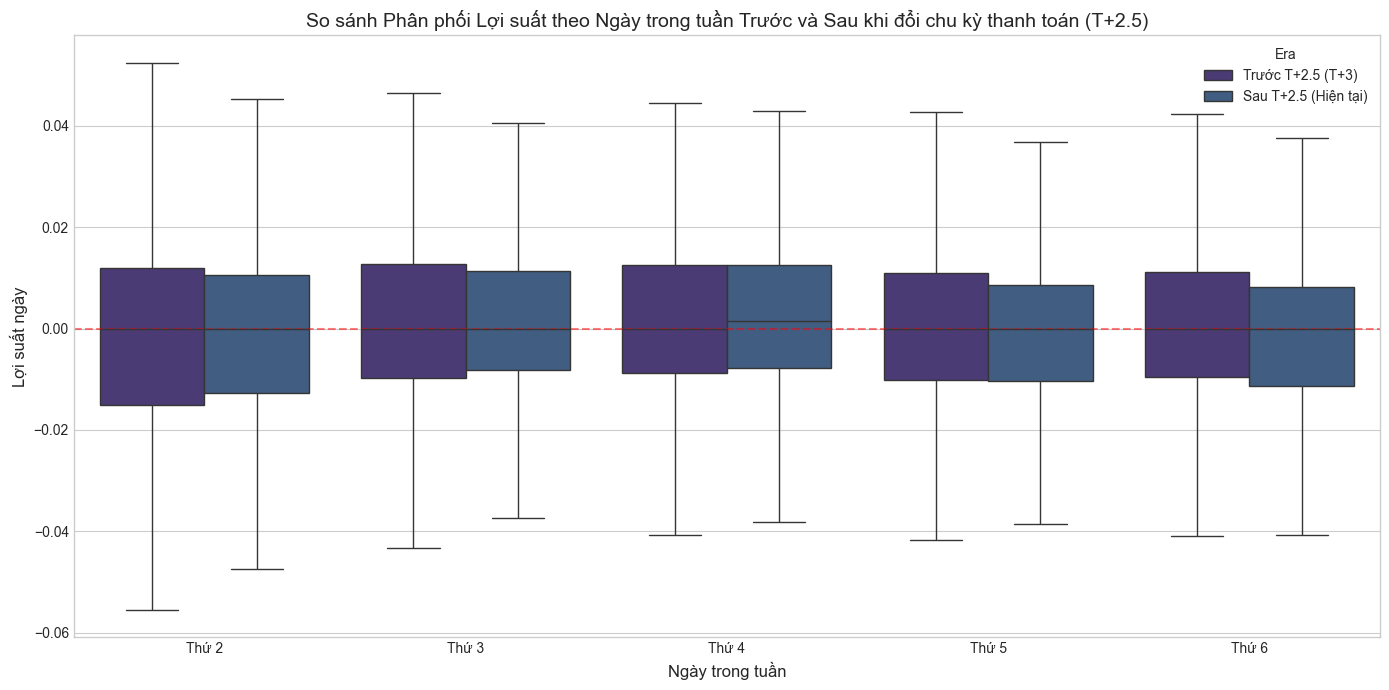

In [9]:
# Thu thập dữ liệu toàn bộ rổ
full_returns_data = []
for fpath in csv_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    df['timestamps'] = pd.to_datetime(df['timestamps'])
    df['returns'] = np.log(df['close'] / df['close'].shift(1))
    df['weekday'] = df['timestamps'].dt.weekday  # 0: Thứ 2, 4: Thứ 6
    df = df.dropna()
    
    # Chia làm 2 tập trước/sau mốc T+2.5
    df_pre = df[df['timestamps'] < '2022-08-29'].copy()
    df_post = df[df['timestamps'] >= '2022-08-29'].copy()
    
    df_pre['Era'] = 'Trước T+2.5 (T+3)'
    df_post['Era'] = 'Sau T+2.5 (Hiện tại)'
    
    full_returns_data.append(df_pre[['returns', 'weekday', 'Era']])
    full_returns_data.append(df_post[['returns', 'weekday', 'Era']])

all_returns_df = pd.concat(full_returns_data, ignore_index=True)
weekday_names = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6'}
all_returns_df['weekday_name'] = all_returns_df['weekday'].map(weekday_names)

# Vẽ biểu đồ hộp Boxplot để so sánh hành vi
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=all_returns_df, 
    x='weekday_name', 
    y='returns', 
    hue='Era', 
    order=['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6'],
    showfliers=False  # Ẩn ngoại lai để thấy rõ phân phối
)
plt.title("So sánh Phân phối Lợi suất theo Ngày trong tuần Trước và Sau khi đổi chu kỳ thanh toán (T+2.5)")
plt.ylabel("Lợi suất ngày")
plt.xlabel("Ngày trong tuần")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Gom cụm tương quan chéo (Cross-Sectional Clustermap)

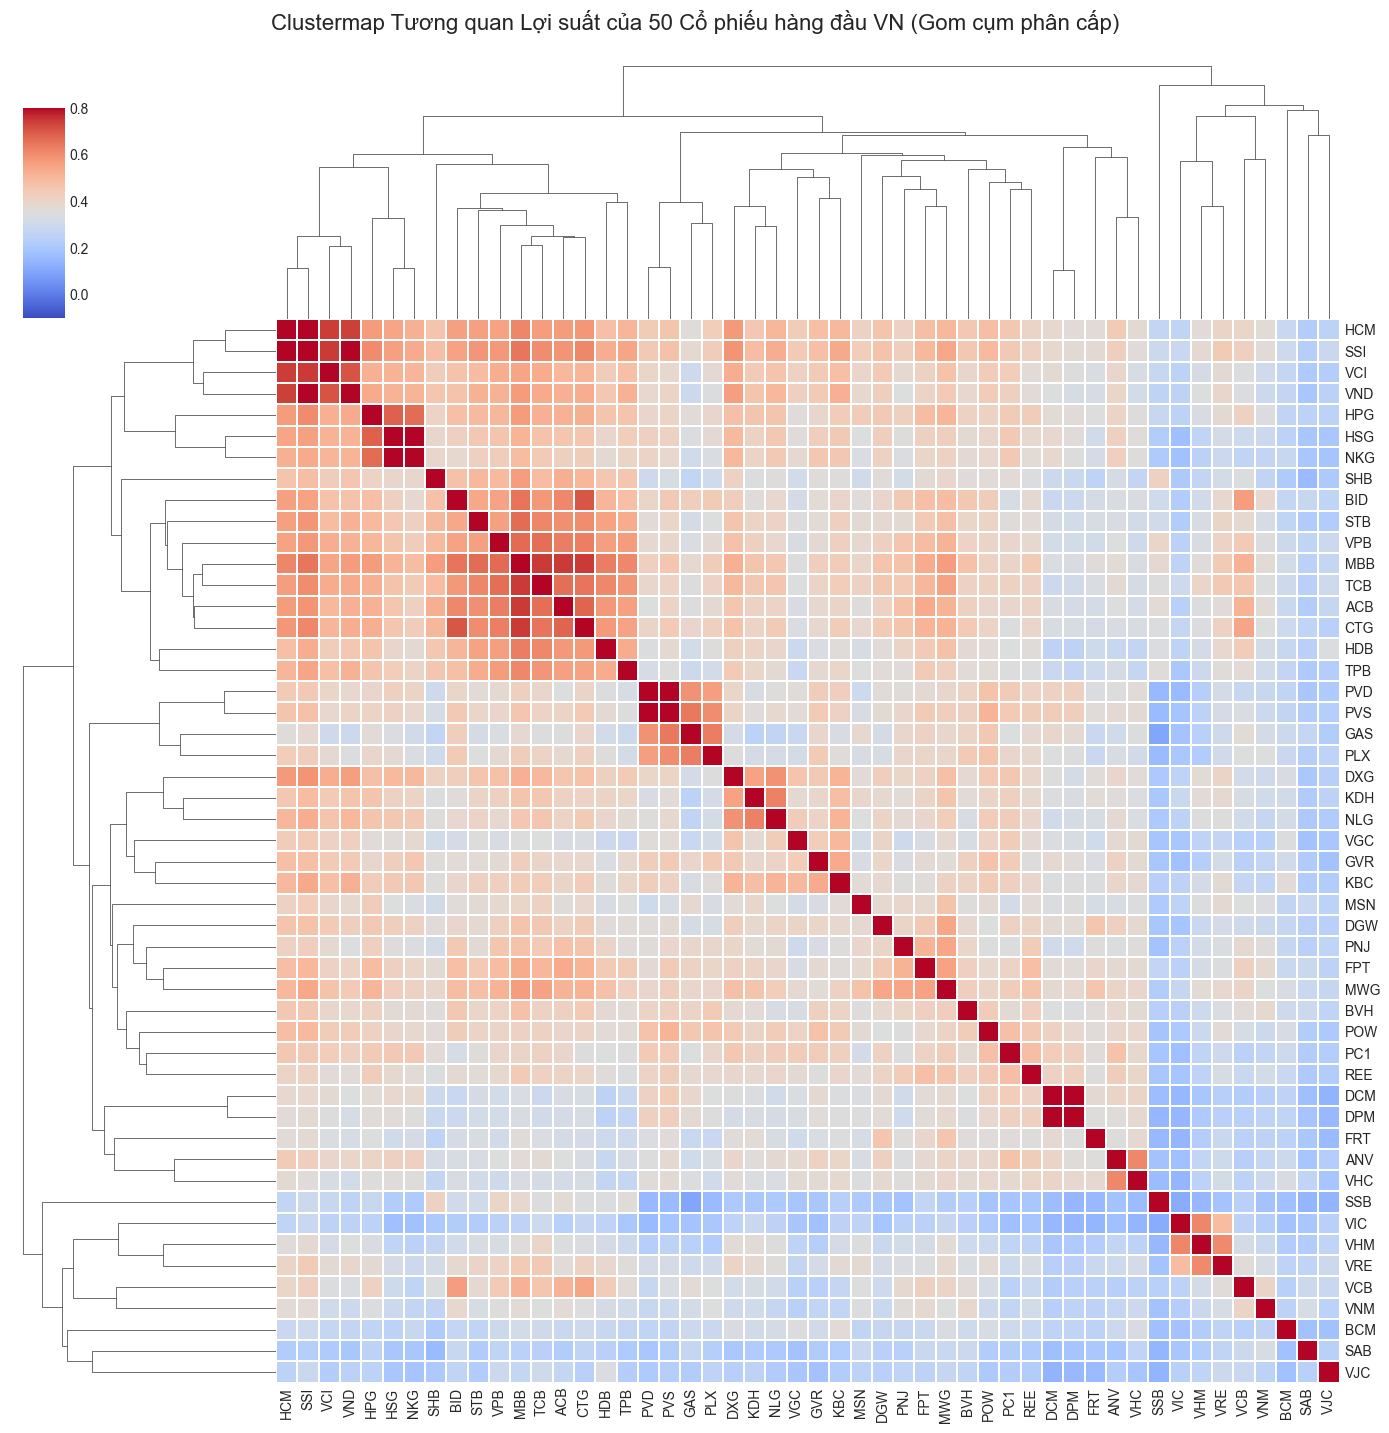

In [10]:
returns_dict = {}
for fpath in csv_files:
    symbol = os.path.splitext(os.path.basename(fpath))[0]
    df = pd.read_csv(fpath)
    df['timestamps'] = pd.to_datetime(df['timestamps'])
    df = df.set_index('timestamps').sort_index()
    returns_dict[symbol] = np.log(df['close'] / df['close'].shift(1))

returns_all_df = pd.DataFrame(returns_dict).dropna(how='all')
corr_matrix = returns_all_df.corr().fillna(0)

sns.clustermap(
    corr_matrix, 
    cmap="coolwarm", 
    vmin=-0.1, vmax=0.8, 
    figsize=(14, 14), 
    linewidths=0.03,
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)
plt.suptitle("Clustermap Tương quan Lợi suất của 50 Cổ phiếu hàng đầu VN (Gom cụm phân cấp)", y=1.02)
plt.show()

## 11. Minh họa mô phỏng cắt trị số chuẩn hóa (Clipping Simulation)

In [11]:
# Chọn mã biến động mạnh SSI để mô phỏng Z-score trượt cục bộ
df_ssi = pd.read_csv(os.path.join(DATA_DIR, "SSI.csv"))

feature_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
data_matrix = df_ssi[feature_cols].values
window_size = 126

# Đếm số điểm bị kẹp ngoài ngưỡng [-5.0, 5.0] trên toàn chuỗi
clipped_counts = {col: 0 for col in feature_cols}
total_pts = (len(data_matrix) - window_size + 1) * window_size

for i in range(len(data_matrix) - window_size + 1):
    sub_window = data_matrix[i : i + window_size]  # (126, 6)
    mean = np.mean(sub_window, axis=0)
    std = np.std(sub_window, axis=0) + 1e-5
    
    z_scored = (sub_window - mean) / std
    
    # Tính số điểm vượt ngưỡng 5.0
    for col_idx, col_name in enumerate(feature_cols):
        outside_count = np.sum((z_scored[:, col_idx] > 5.0) | (z_scored[:, col_idx] < -5.0))
        clipped_counts[col_name] += outside_count

print("Tỷ lệ dữ liệu bị cắt (clipping rate) trên từng cột tại ngưỡng 5.0:")
for col in feature_cols:
    rate = (clipped_counts[col] / total_pts) * 100
    print(f"- Cột {col:7s}: {clipped_counts[col]} điểm bị clip ({rate:.4f}%)")

print("\nGiải thích: Nếu tỷ lệ clip < 1% trên tất cả các cột, ngưỡng 5.0 là hoàn hảo,")
print("chỉ loại bỏ các biến động cực đoan đột xuất mà không làm mất thông tin hữu ích của chuỗi.")

Tỷ lệ dữ liệu bị cắt (clipping rate) trên từng cột tại ngưỡng 5.0:
- Cột open   : 0 điểm bị clip (0.0000%)
- Cột high   : 0 điểm bị clip (0.0000%)
- Cột low    : 0 điểm bị clip (0.0000%)
- Cột close  : 0 điểm bị clip (0.0000%)
- Cột volume : 171 điểm bị clip (0.0725%)
- Cột amount : 228 điểm bị clip (0.0967%)

Giải thích: Nếu tỷ lệ clip < 1% trên tất cả các cột, ngưỡng 5.0 là hoàn hảo,
chỉ loại bỏ các biến động cực đoan đột xuất mà không làm mất thông tin hữu ích của chuỗi.


## 12. Phân phối log-scale của trường Amount (Giá trị giao dịch)

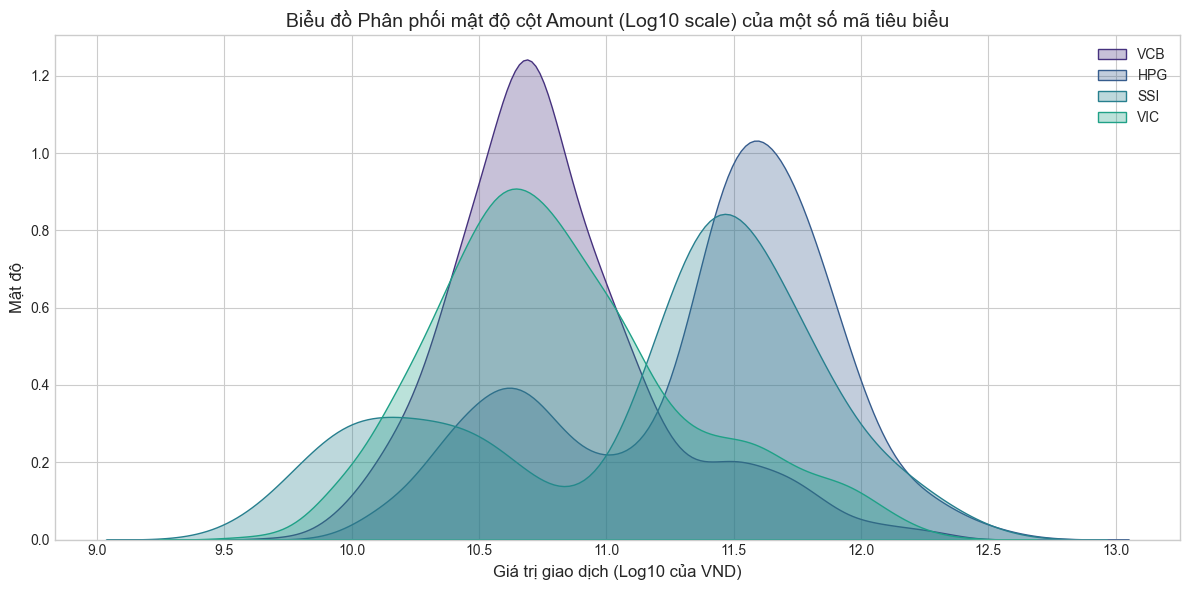

In [12]:
plt.figure(figsize=(12, 6))
for sym in ['VCB', 'HPG', 'SSI', 'VIC']:
    df = pd.read_csv(os.path.join(DATA_DIR, f"{sym}.csv"))
    # Dùng log10 để so sánh phân phối ở các quy mô giao dịch khác nhau
    sns.kdeplot(np.log10(df['amount'] + 1e-5), label=sym, fill=True, alpha=0.3)

plt.title("Biểu đồ Phân phối mật độ cột Amount (Log10 scale) của một số mã tiêu biểu")
plt.xlabel("Giá trị giao dịch (Log10 của VND)")
plt.ylabel("Mật độ")
plt.legend()
plt.tight_layout()
plt.show()